In [22]:
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal
from dotenv import load_dotenv
from typing import Annotated
from langgraph.graph import add_messages
from langchain.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

In [23]:
class State(TypedDict):
    messages: Annotated[list, add_messages] #Append the messages form the user

In [24]:
@tool()
def get_stock_price(symbol: str) -> float:
    """Get the current stock price for a given symbol."""
    return {
        "MSFT": 200.3,
        "AAPL": 100.4,
        "AMZN": 150.0   
    }.get(symbol, 0.0)

tools = [get_stock_price]

llm = init_chat_model("google_genai:gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("chatbot_node", chatbot)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node", tools_condition)
# builder.add_edge("chatbot_node", END)

graph = builder.compile()

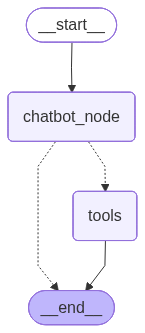

In [25]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [26]:
message = {"role": "user", "content": "What is the price of MSFT"}

response = graph.invoke({"messages": [message]})

response["messages"]

[HumanMessage(content='What is the price of MSFT', additional_kwargs={}, response_metadata={}, id='559a5f0f-c825-4234-9f0c-1fb5af94f877'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "MSFT"}'}, '__gemini_function_call_thought_signatures__': {'76887807-ecab-480b-9d1b-ea67d9fee483': 'CpgCAb4+9vtbRdpp6Za2RtCWbIxWlBcVzzbv7YqgzAMpFDAlxVYIqAIyNH6vR3PGmHRIvXgl1LbYh5MlVTCGejUChwvul7FUt5Ogxhzak0eAfL92OFfNSL49/BzBvgFIxjUCJ0SZumwNI1ZgINHZ4CfhzNNfcDUG0O6lwHnOWYup8WFYAYB52iLiUXXItIaIfvea8NPDmgzGNLEqySDfBPzFmpr9IZijDGiZjLcXNbiut3QvUpBdnHkJMdjevTMFgyA37JsR1brVduHLoWQbTiDRrHXl2VVXfthiURYzGtNXuFyAY9nl3vJnfeawpoFLoMvTxekzZR7ugSQssc0stz4YzC7QqJJwugpbro8kjB/xGXYC5av0myUPFA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d0f5c-69f4-7ac0-93f7-6131411952b3-0', tool_calls=[{'name': 'get_stock_price', 'args': {'symbol': 'MSFT'}, 'id': '7

In [27]:
message = {"role": "user", "content": "I want to buy 20 AMZN using current price. Then 15 MSFT. What will be the total cost?"}

response = graph.invoke({"messages": [message]})

response["messages"]

[HumanMessage(content='I want to buy 20 AMZN using current price. Then 15 MSFT. What will be the total cost?', additional_kwargs={}, response_metadata={}, id='8998fac7-82ea-40b5-bb87-4d53fa719ee5'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_stock_price', 'arguments': '{"symbol": "AMZN"}'}, '__gemini_function_call_thought_signatures__': {'06266d3e-8c2f-4758-8689-2926481c4b9b': 'CokDAb4+9vtLslfQMVODzud+MCyMr8DQ5zOkNQvJDuzutlxy+OWAlGzBXAa28SAOkJfg+gmpH979mJVTijc4St7MoUzOaTa+KFdA01+SVdnqA2RpriAQq+Yl5Dh5xpnUAj+fpYpyiSXrQJ/hIfOpXVihSNTwoilnxnX6+O5riLgwS+kEKZqyQN5ugCTRmX+cKwvpe205ag8nsacQVp7N+LdUpbItLGWT5b7bQYkgYBcaoEdW8bRO+nEpfWNt7KrRGoFqjL4chuaMosUnbh8BV1/tyewtTAsAn9RJA1zIBou0eCAYndpH7rbjJc6ze/GKQW9+rK867cM8n1gFEk6HpHJwU3fmYkqMB1W4PoiUz9P2DIaK1wxofP4Blqiavmltv+cqtEiow8bxboxxNaQ2zQObFt9Z/UPad8HWOD4pEq4zAUsIyZPBgPRdNtXA7NAw/9IhuHOr0btx2zjmCuua103uK6uWVRUM8eOMXeGWewLab0YxeqS6t+3NQZfmrk25I/Y5f1YCguxNiY2J'}}, response_metadata={'finish_reason': 'STOP', 'model_name'